# Score Nrf2 against imid substrates

Purpose:
Score Nrf2 domain model agains other Imid substrates using MaSIF-mimicry

In [6]:
import os
import pandas as pd
import numpy as np

repo_root = !git rev-parse --show-toplevel
repo_root = repo_root[0]
os.chdir(repo_root)

data_dir = "data/Nrf2"
os.makedirs(data_dir, exist_ok=True)

input_dir = os.path.join(data_dir, "input")
os.makedirs(input_dir, exist_ok=True)
preprocess_dir = os.path.join(data_dir, "preprocess")
os.makedirs(preprocess_dir, exist_ok=True)


# imid structures (in the format of {pdb_id}_{substrate_chain}_{CRBN_chain})
imid_structures = [
    "5FQD_C_B",  
    "6h0f_C_B",
    "6h0g_C_B",
    "6xk9_A_C",
    "9dwv_C_B",
    "9dww_P_C",
    "9nfq_C_B",
    "9nfr_C_B",
    "9ngt_C_B",
    "9Q2D_B_A",
    "5HXB_A_C",
    "9DWV_C_B"
]

# Nrf2 structure
domainome_dir = "/work/lpdi/users/shxiao/masif_seed/masif/data/masif_human_proteome_domains_merged"
nrf2_model_id = "Q16236-F1-dom-02_A"
nrf2_pdb_path = os.path.join(input_dir, "data_preparation", "01-benchmark_pdbs", f"{nrf2_model_id}.pdb")


# MaSIF repo parameters
MASIF_ROOT = "/scratch/ymeng/masif_seed"
IMAGE = "/scratch/ymeng/masif_seed/masif_mimicry/masif_mimicry.sif"

In [33]:
from Bio.PDB import PDBList, PDBParser, MMCIFParser, PDBIO
from Bio.PDB.Structure import Structure
from Bio.PDB.Model import Model
import copy

pdb_parser = PDBParser(QUIET=True)
cif_parser = MMCIFParser(QUIET=True)
pdbl = PDBList()


def load_structure(pdb_id, cache_dir):
    """Download structure as PDB; fall back to mmCIF (parsed in-memory)."""
    raw_pdb = pdbl.retrieve_pdb_file(pdb_id, pdir=cache_dir, file_format="pdb")
    if raw_pdb and os.path.isfile(raw_pdb):
        return pdb_parser.get_structure(pdb_id, raw_pdb)

    print(f"  PDB unavailable for {pdb_id}, trying mmCIF...")
    raw_cif = pdbl.retrieve_pdb_file(pdb_id, pdir=cache_dir, file_format="mmCif")
    if not raw_cif or not os.path.isfile(raw_cif):
        raise FileNotFoundError(f"Could not download {pdb_id} as PDB or mmCIF")
    return cif_parser.get_structure(pdb_id, raw_cif)


for imid in imid_structures:
    pdb_id, substrate_chain, _crbn_chain = imid.split("_")
    pdb_id = pdb_id.upper()
    out_path = os.path.join(input_dir, f"{pdb_id}_{substrate_chain}.pdb")

    if os.path.isfile(out_path):
        print(f"exists: {out_path}")
        continue

    struct = load_structure(pdb_id, input_dir)

    new_struct = Structure(f"{pdb_id}_{substrate_chain}")
    model = Model(0)
    new_struct.add(model)
    model.add(copy.deepcopy(struct[0][substrate_chain]))

    io = PDBIO()
    io.set_structure(new_struct)
    io.save(out_path)
    print(f"saved: {out_path}")

exists: data/Nrf2/input/5FQD_C.pdb
exists: data/Nrf2/input/6H0F_C.pdb
exists: data/Nrf2/input/6H0G_C.pdb
exists: data/Nrf2/input/6XK9_A.pdb
exists: data/Nrf2/input/9DWV_C.pdb
exists: data/Nrf2/input/9DWW_P.pdb
exists: data/Nrf2/input/9NFQ_C.pdb
exists: data/Nrf2/input/9NFR_C.pdb
exists: data/Nrf2/input/9NGT_C.pdb
exists: data/Nrf2/input/9Q2D_B.pdb
exists: data/Nrf2/input/5HXB_A.pdb
exists: data/Nrf2/input/9DWV_C.pdb


In [43]:
import subprocess
import shutil

rows = []
seen = set()
EvoEF2_bin = "/scratch/ymeng/tricomplex-design/EvoEF2/EvoEF2"
repair_dir = os.path.join(input_dir, "repair")
os.makedirs(repair_dir, exist_ok=True)

for imid in imid_structures:
    pdb_id, substrate_chain, _crbn_chain = imid.split("_")
    pdb_id = pdb_id.upper()
    key = (pdb_id, substrate_chain)
    if key in seen:
        continue
    seen.add(key)
    pdb_path = os.path.abspath(os.path.join(input_dir, f"{pdb_id}_{substrate_chain}.pdb"))
    repaired_pdb = os.path.abspath(os.path.join(repair_dir, f"{pdb_id}_{substrate_chain}.pdb"))
    evoef2_output = f"{pdb_id}_{substrate_chain}_Repair.pdb"

    # Only run EvoEF2 if the repaired file does not exist yet
    if not os.path.isfile(repaired_pdb):
        if not os.path.isfile(evoef2_output):
            print(f"Running EvoEF2 RepairStructure for {pdb_path} ...")
            try:
                subprocess.run([
                    EvoEF2_bin,
                    "--command=RepairStructure",
                    f"--pdb={pdb_path}"
                ], check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            except subprocess.CalledProcessError as e:
                print(f"Error running EvoEF2 for {pdb_path}: {e}")

        if os.path.isfile(evoef2_output):
            # After *_Repair.pdb is generated, move to repair directory, rename without _Repair
            shutil.move(evoef2_output, repaired_pdb)
        else:
            print(f"Expected repaired PDB at {evoef2_output}, but not found.")

    rows.append({
        "pdb": pdb_id,
        "protein_chain": substrate_chain,
        "lig_name": "",
        "lig_chain": "",
        "resid": "",
        "pdb_path": repaired_pdb,
        "lig_path": "",
        "infer_reduce_dict": "true",
    })

config_df = pd.DataFrame(rows)
config_path = os.path.join(data_dir, "config.csv")
config_df.to_csv(config_path, index=False)
print(f"Wrote {len(config_df)} rows to {config_path}")
config_df

Wrote 11 rows to data/Nrf2/config.csv


,pdb,protein_chain,lig_name,lig_chain,resid,pdb_path,lig_path,infer_reduce_dict
0,5FQD,C,,,,/scratch/ymeng/masif_seed/masif_mimicry/data/N...,,true
1,6H0F,C,,,,/scratch/ymeng/masif_seed/masif_mimicry/data/N...,,true
2,6H0G,C,,,,/scratch/ymeng/masif_seed/masif_mimicry/data/N...,,true
3,6XK9,A,,,,/scratch/ymeng/masif_seed/masif_mimicry/data/N...,,true
4,9DWV,C,,,,/scratch/ymeng/masif_seed/masif_mimicry/data/N...,,true
5,9DWW,P,,,,/scratch/ymeng/masif_seed/masif_mimicry/data/N...,,true
6,9NFQ,C,,,,/scratch/ymeng/masif_seed/masif_mimicry/data/N...,,true
7,9NFR,C,,,,/scratch/ymeng/masif_seed/masif_mimicry/data/N...,,true
8,9NGT,C,,,,/scratch/ymeng/masif_seed/masif_mimicry/data/N...,,true
9,9Q2D,B,,,,/scratch/ymeng/masif_seed/masif_mimicry/data/N...,,true


___
Manually launch search mimicry site selection jobs
- First, search for Q16236-F1-dom-02_A using 6H0G
- Then, find the 5 p1_ource_site from Q16236-F1-dom-02_A that gave the highest MaSIF-score, use these sites to search against other Imid substrates

In [ ]:
search_out_dir = "/scratch/ymeng/masif_seed/masif_mimicry/data/Nrf2/search_results/Nrf2"

import glob

df_results = pd.DataFrame()

for out_csv_path in glob.glob(os.path.join(search_out_dir, "*", "*.csv")):
    df = pd.read_csv(out_csv_path)
    df_results = pd.concat([df_results, df])

df_results.shape

(185, 17)

In [14]:
# Deduplicate df_results by: for a given P1_id, select the group with the highest cluster_size, then select the row with the highest MaSIF-score

def deduplicate_results(df):
    # Build the dedup df by collecting Series rather than DataFrames or dicts
    dedup_rows = []
    for p1_id, group in df.groupby("P1_id"):
        # Find the largest cluster_size
        max_cluster_size = group["cluster_size"].max()
        largest_clusters = group[group["cluster_size"] == max_cluster_size]
        # Of those, pick row with highest MaSIF-score
        idx = largest_clusters["MaSIF-score"].idxmax()
        # Append as pd.Series (homogeneous row)
        dedup_rows.append(group.loc[idx])
    # Use pd.concat to combine rows (all Series of same columns)
    return pd.concat(dedup_rows, axis=1).T.reset_index(drop=True)

df_results_dedup = deduplicate_results(df_results)
df_results_dedup


,P1_id,P2_id,P1_source_ppi_id,P2_source_ppi_id,P1_source_site,P2_source_site,P1_source_TMscore,P2_source_TMscore,P1_source_iface,P2_source_iface,MaSIF-score,flattened_transform,ca_clash,heavy_atom_clash,cluster_id,cluster_size,cluster_mean_rmsd
0,5FQD_C,Q16236-F1-dom-02_A,p1,p1,3129,488,0.09145,0.43527,0.275554,0.565463,0.454074,"-0.6378573199868383,0.7687533710972388,0.04643...",0,0,0,2.0,0.225338
1,6H0F_C,Q16236-F1-dom-02_A,p1,p1,12,751,0.39793,0.28846,0.293896,0.586193,0.566068,"0.4978600380328606,-0.0671929911985002,0.86465...",0,0,0,17.0,1.17268
2,6H0G_C,Q16236-F1-dom-02_A,p1,p1,731,751,0.36725,0.2692,0.137541,0.586193,0.601992,"-0.0835537302707267,-0.4070636054966734,-0.909...",0,0,1,51.0,1.289039
3,9DWV_C,Q16236-F1-dom-02_A,p1,p1,253,488,0.20818,0.28516,0.435954,0.565463,0.50056,"0.2110390361136096,0.9772565023517784,-0.02079...",0,0,0,15.0,1.167824
4,9NFQ_C,Q16236-F1-dom-02_A,p1,p1,5388,940,0.09428,0.42844,0.356303,0.681921,0.457203,"-0.6752333531493668,-0.7269536541749209,0.1248...",0,0,0,2.0,1.343428
5,9NGT_C,Q16236-F1-dom-02_A,p1,p1,1784,751,0.23597,0.41365,0.354854,0.586193,0.496042,"-0.5214794634248705,-0.8309075849707492,0.1940...",0,0,0,20.0,5.219088
6,9Q2D_B,Q16236-F1-dom-02_A,p1,p1,5604,527,0.08661,0.36592,0.5513,0.678172,0.476998,"0.3720978719468923,-0.5004717750126225,0.78171...",0,0,1,10.0,2.620376


In [21]:
import matplotlib.pyplot as plt

# Get all possible P1_ids
P1_id_all = ["_".join([p.upper() for p in x.split("_")[:2]]) for x in imid_structures]

df_plot = df_results_dedup[["P1_id", "MaSIF-score", "cluster_size"]].copy()

# For any P1_id in P1_id_all not in df_plot, add a row with 0 for MaSIF-score and cluster_size
current_ids = set(df_plot["P1_id"])
missing_ids = set(P1_id_all) - current_ids
if missing_ids:
    placeholders = pd.DataFrame({
        "P1_id": list(missing_ids),
        "MaSIF-score": 0,
        "cluster_size": 0
    })
    df_plot = pd.concat([df_plot, placeholders], ignore_index=True)



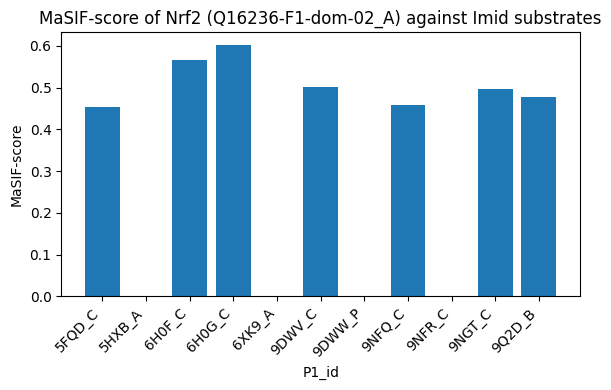

In [25]:
# Plot MaSIF-score

# Sort by P1_id for nice plotting order
df_plot = df_plot.sort_values("P1_id", ascending=True)
df_plot["cluster_size"] = df_plot["cluster_size"].astype(float)

plt.figure(figsize=(6, 4))
bars = plt.bar(df_plot["P1_id"], df_plot["MaSIF-score"], color='C0')  # default color, not colored by cluster size

plt.xlabel("P1_id")
plt.ylabel("MaSIF-score")
plt.title("MaSIF-score of Nrf2 (Q16236-F1-dom-02_A) against Imid substrates")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

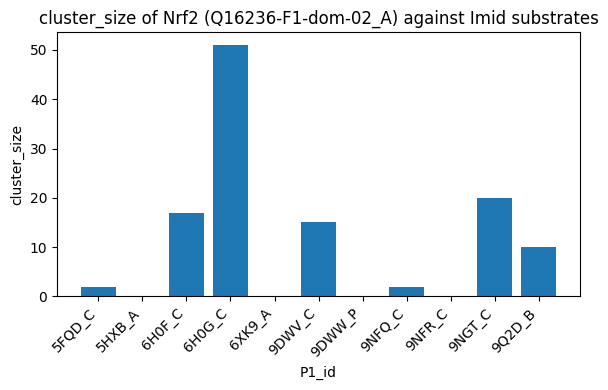

In [26]:
# Plot cluster_size

# Sort by P1_id for nice plotting order
df_plot = df_plot.sort_values("P1_id", ascending=True)
df_plot["cluster_size"] = df_plot["cluster_size"].astype(float)

plt.figure(figsize=(6, 4))
bars = plt.bar(df_plot["P1_id"], df_plot["cluster_size"], color='C0')  # default color, not colored by cluster size

plt.xlabel("P1_id")
plt.ylabel("cluster_size")
plt.title("cluster_size of Nrf2 (Q16236-F1-dom-02_A) against Imid substrates")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()